In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
import seaborn as sns
import pandas as pd

import cv2

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.preprocessing import image

import pickle
from tqdm import tqdm
import time
import os
from pathlib import Path
import kagglehub

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


In [ ]:
# The path to the 'raw-img' directory
raw_img_path = os.path.join(path, 'raw-img')

# List the contents of the 'raw-img' directory
raw_img_contents = os.listdir(raw_img_path)
print(f"Contents of the '{raw_img_path}' directory:")
print(raw_img_contents)

Contents of the '/kaggle/input/animals10/raw-img' directory:
['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']


In [ ]:
translation_table = { "cane": "dog",
                      "cavallo": "horse",
                      "elefante": "elephant",
                      "farfalla": "butterfly",
                      "gallina": "chicken",
                      "gatto": "cat",
                      "mucca": "cow",
                      "pecora": "sheep",
                      "scoiattolo": "squirrel",
                      "ragno": "spider"
                      }

In [ ]:
def load_dataset(dataset_path, translation_table):
        """
        Load images from directory structure:
        dataset_path/
            cavallo/
            pecora/
            elefante/
            ...
        """

        image_paths = []
        labels = []

        # Iterate through the directories in raw_img_path (each directory is a label)
        for label in os.listdir(dataset_path):
            label_path = os.path.join(dataset_path, label)
            # Check if it's a directory
            if os.path.isdir(label_path):
                # Iterate through the files in the label directory
                for image_file in tqdm(os.listdir(label_path), desc=f'Loading {translation_table[label]}: '):
                    image_path = os.path.join(label_path, image_file)
                    # Check if it's a file
                    if os.path.isfile(image_path):
                        image_paths.append(image_path)
                        labels.append(translation_table[label])

        # Create a pandas DataFrame
        df = pd.DataFrame({'image_path': image_paths, 'label': labels})

        return df

In [ ]:
# Load the VGG16 model with pre-trained ImageNet weights and including the top layers
base_model = VGG16(weights='imagenet', include_top=True)
# Create a new model that outputs from the 'fc2' layer
model_fc2 = tf.keras.Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


In [ ]:
def extract_cnn_features(image_paths, batch_size=32, img_size=(224, 224)):
      """Extract CNN features in batches to save memory from a DataFrame containing 'image_data' column"""
      print("Extracting CNN features using VGG16...")
      print(f"  Architecture: VGG16 (ImageNet pre-trained)")
      print(f"  Layer: fc2 (last fully connected layer before output)")
      print(f"  Parameters: include_top=True")
      print(f"  Batch size: {batch_size}")

      features = []
      current_batch_images = []

      # Check for GPU availability
      gpus = tf.config.list_physical_devices('GPU')
      if gpus:
          device_name = '/GPU:0'
          print("  Using GPU for CNN feature extraction.")
      else:
          device_name = '/CPU:0'
          print("  Using CPU for CNN feature extraction.")

      with tf.device(device_name):
          # Iterate over the 'image_data' column of the DataFrame
          for i, path in enumerate(tqdm(image_paths, desc='Extracting VGG16 Features: ')):
              img_array_data = cv2.imread(path)
              # Fix: Pass img_size as a tuple (width, height)
              img_array_data = cv2.resize(img_array_data, img_size)
              img_rgb = cv2.cvtColor(img_array_data, cv2.COLOR_BGR2RGB)
              img_preprocessed = vgg_preprocess(np.expand_dims(img_rgb, axis=0)) # Add batch dimension for preprocessing

              current_batch_images.append(img_preprocessed[0]) # Append the image without the extra batch dimension

              # If batch is full or it's the last image
              if len(current_batch_images) == batch_size or i == len(image_paths) - 1:
                  batch_tensor = np.array(current_batch_images) # Convert list of images to a single batch tensor
                  batch_features = model_fc2.predict(batch_tensor, verbose=0)
                  features.extend(batch_features)
                  current_batch_images = [] # Reset batch

      features = np.array(features)
      print(f"  Feature dimension: {features.shape[1]} per image")
      print(f"  Total features extracted: {features.shape[0]}")
      return features

In [ ]:
data = load_dataset(raw_img_path, translation_table)

Loading butterfly: 100%|██████████| 2112/2112 [00:02<00:00, 816.15it/s]


In [ ]:
data.head()

,image_path,label
0,/kaggle/input/animals10/raw-img/cavallo/OIP-md...,horse
1,/kaggle/input/animals10/raw-img/cavallo/OIP-TP...,horse
2,/kaggle/input/animals10/raw-img/cavallo/OIP-jl...,horse
3,/kaggle/input/animals10/raw-img/cavallo/OIP-F4...,horse
4,/kaggle/input/animals10/raw-img/cavallo/OIP-UF...,horse


In [ ]:
if not os.path.exists('/content/drive/MyDrive/CS231/vgg16_label_encoder.pkl'):

  encoder = LabelEncoder()
  data['label_encoded'] = encoder.fit(data['label'])

else:
  encoder = pickle.load(open('/content/drive/MyDrive/CS231/vgg16_label_encoder.pkl', 'rb'))

data['label_encoded'] = encoder.transform(data['label'])

In [ ]:
data.head()

,image_path,label,label_encoded
0,/kaggle/input/animals10/raw-img/cavallo/OIP-md...,horse,6
1,/kaggle/input/animals10/raw-img/cavallo/OIP-TP...,horse,6
2,/kaggle/input/animals10/raw-img/cavallo/OIP-jl...,horse,6
3,/kaggle/input/animals10/raw-img/cavallo/OIP-F4...,horse,6
4,/kaggle/input/animals10/raw-img/cavallo/OIP-UF...,horse,6


In [ ]:
if not os.path.exists('./drive/MyDrive/CS231/vgg16_features.pkl'):

    # Extract
    features = extract_cnn_features(data['image_path'])
    print(features.shape)

    # Save
    import pickle

    # Define the filename for saving features
    features_filename = './drive/MyDrive/CS231/vgg16_features.pkl'

    # Save the features to a file
    with open(features_filename, 'wb') as f:
        pickle.dump(features, f)

    print(f"VGG16 features saved to '{features_filename}'")
else:
  features = pickle.load(open('./drive/MyDrive/CS231/vgg16_features.pkl', 'rb'))

In [ ]:
# Assuming 'features' contains the extracted VGG16 features
X = features
# Assuming 'data['label_encoded']' contains the encoded labels
y = data['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# StandardScaler object
scaler_filename = '/content/drive/MyDrive/CS231/vgg16_scaler.pkl'

if not os.path.exists(scaler_filename):

  # Initialize and fit StandardScaler on the training data
  scaler = StandardScaler()


  # Saving
  with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
  print(f"StandardScaler object saved to '{scaler_filename}'")

else:
  scaler = pickle.load(open(scaler_filename, 'rb'))

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaled successfully.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Training data shape: (20943, 4096)
Testing data shape: (5236, 4096)

Data scaled successfully.
Scaled training data shape: (20943, 4096)
Scaled testing data shape: (5236, 4096)


### PCA

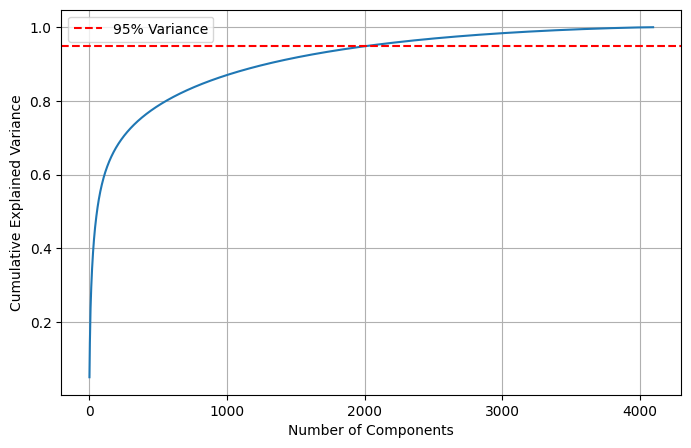

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Fit PCA with all components to see the full picture
pca = PCA().fit(X_train_scaled)

# Plotting
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()
plt.show()

In [ ]:
if not os.path.exists('/content/drive/MyDrive/CS231/vgg16_pca.pkl'):

  from sklearn.decomposition import PCA

  # Initialize PCA with 500 components
  pca = PCA(n_components=500)



  print(f"Original training data shape: {X_train_scaled.shape}")
  print(f"PCA transformed training data shape: {X_train_pca.shape}")
  print(f"Original testing data shape: {X_test_scaled.shape}")
  print(f"PCA transformed testing data shape: {X_test_pca.shape}")

  # Optional: Check the explained variance ratio
  print(f"\nTotal explained variance by 500 components: {pca.explained_variance_ratio_.sum():.4f}")

else:
  pca = pickle.load(open('/content/drive/MyDrive/CS231/vgg16_pca.pkl', 'rb'))

# Fit PCA on the scaled training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform the scaled testing data using the fitted PCA model
X_test_pca = pca.transform(X_test_scaled)

### SVM

In [ ]:
model_filename = '/content/drive/MyDrive/CS231/vgg16_svm_model.pkl'
# Define the parameter grid for GridSearchCV
param_grid = [
    {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1], 'kernel': ['rbf'], 'class_weight': ['balanced']},
    {'C': [0.1, 1, 10], 'kernel': ['linear'], 'class_weight': ['balanced']}
]

# Instantiate a Support Vector Classifier (SVC) object
svc = SVC(random_state=42)

# Instantiate GridSearchCV
# cv=2 for cross-validation folds
# verbose=2 to display progress
# n_jobs=-1 to use all available CPU cores
grid_search = GridSearchCV(svc, param_grid, cv=2, verbose=2, n_jobs=-1)

try:
  if os.path.exists(model_filename):
    grid_search = pickle.load(open(model_filename, 'rb'))
    print(f"Successfully loaded existing GridSearchCV object from '{model_filename}'")
  else:
    # If the file doesn't exist, we need to train a new model
    raise FileNotFoundError # This will be caught by the except block
except (EOFError, FileNotFoundError, pickle.UnpicklingError) as e:
  print(f"Model file '{model_filename}' not found or is corrupted (Error: {e}). Training and saving a new model...")
  if os.path.exists(model_filename):
    os.remove(model_filename) # Delete the corrupted file

  print("Starting GridSearchCV to find optimal SVC hyperparameters...")
  # Fit GridSearchCV to the PCA-transformed training data
  grid_search.fit(X_train_pca, y_train)

  print("GridSearchCV completed.")
  print(f"Best parameters found by GridSearchCV: {grid_search.best_params_}")

  with open(model_filename, 'wb') as file:
    pickle.dump(grid_search, file) # Save the entire GridSearchCV object
  print(f"GridSearchCV object saved to '{model_filename}'")


Successfully loaded existing GridSearchCV object from '/content/drive/MyDrive/CS231/vgg16_svm_model.pkl'


Accuracy Score: 0.9366

Classification Report:
              precision    recall  f1-score   support

   butterfly       0.93      0.96      0.95       422
         cat       0.93      0.95      0.94       334
     chicken       0.98      0.96      0.97       620
         cow       0.80      0.86      0.83       373
         dog       0.93      0.95      0.94       973
    elephant       0.96      0.98      0.97       289
       horse       0.90      0.86      0.88       525
       sheep       0.93      0.84      0.88       364
      spider       0.98      0.98      0.98       964
    squirrel       0.96      0.96      0.96       372

    accuracy                           0.94      5236
   macro avg       0.93      0.93      0.93      5236
weighted avg       0.94      0.94      0.94      5236


Confusion Matrix:


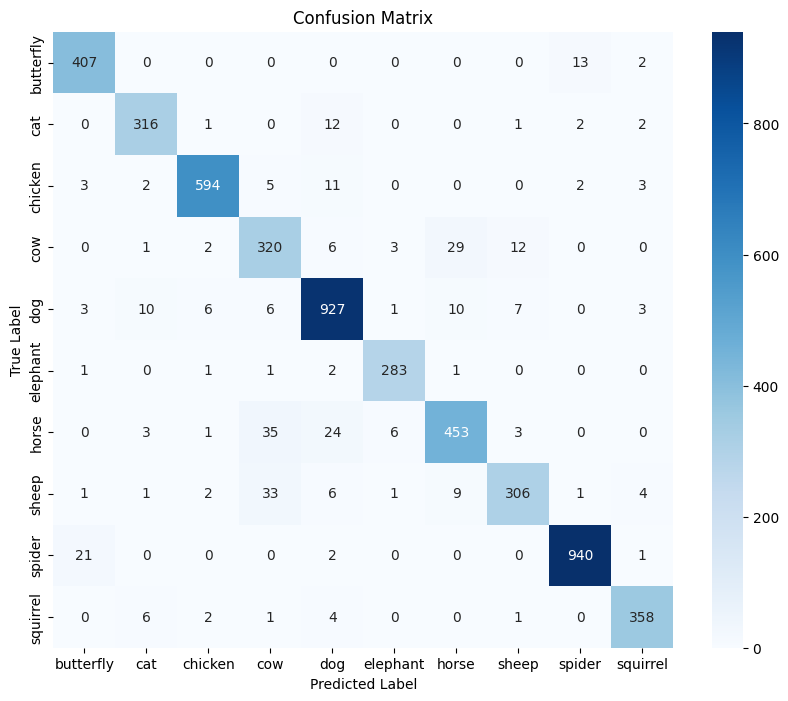

In [ ]:
# Make predictions on the PCA-transformed test data
y_pred = grid_search.predict(X_test_pca)

# Evaluate the model
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model_filename = '/content/drive/MyDrive/CS231/vgg16_random_forest_model.pkl'

# Define the parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'class_weight': ['balanced']
}

# Instantiate a RandomForestClassifier object
rf_clf = RandomForestClassifier(random_state=42)

# Instantiate GridSearchCV
# cv=2 for cross-validation folds
# verbose=2 to display progress
# n_jobs=-1 to use all available CPU cores
grid_search_rf = GridSearchCV(rf_clf, param_grid_rf, cv=2, verbose=2, n_jobs=-1)

try:
  if os.path.exists(random_forest_model_filename):
    grid_search_rf = pickle.load(open(random_forest_model_filename, 'rb'))
    print(f"Successfully loaded existing GridSearchCV object from '{random_forest_model_filename}'")
  else:
    # If the file doesn't exist, we need to train a new model
    raise FileNotFoundError # This will be caught by the except block
except (EOFError, FileNotFoundError, pickle.UnpicklingError) as e:
  print(f"Model file '{random_forest_model_filename}' not found or is corrupted (Error: {e}). Training and saving a new model...")
  if os.path.exists(random_forest_model_filename):
    os.remove(random_forest_model_filename) # Delete the corrupted file

  print("Starting GridSearchCV for Random Forest to find optimal hyperparameters...")
  # Fit GridSearchCV to the PCA-transformed training data
  grid_search_rf.fit(X_train_pca, y_train)

  print("Random Forest GridSearchCV completed.")
  print(f"Best parameters found by Random Forest GridSearchCV: {grid_search_rf.best_params_}")

  with open(random_forest_model_filename, 'wb') as file:
    pickle.dump(grid_search_rf, file) # Save the entire GridSearchCV object
  print(f"Random Forest GridSearchCV object saved to '{random_forest_model_filename}'")

Model file '/content/drive/MyDrive/CS231/vgg16_random_forest_model.pkl' not found or is corrupted (Error: ). Training and saving a new model...
Starting GridSearchCV for Random Forest to find optimal hyperparameters...
Fitting 2 folds for each of 9 candidates, totalling 18 fits
Random Forest GridSearchCV completed.
Best parameters found by Random Forest GridSearchCV: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 300}
Random Forest GridSearchCV object saved to '/content/drive/MyDrive/CS231/vgg16_random_forest_model.pkl'


Best parameters found by Random Forest GridSearchCV: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 300}
Random Forest Accuracy Score: 0.9383

Random Forest Classification Report:
              precision    recall  f1-score   support

   butterfly       0.95      0.97      0.96       422
         cat       0.98      0.90      0.94       334
     chicken       0.98      0.94      0.96       620
         cow       0.86      0.87      0.87       373
         dog       0.93      0.95      0.94       973
    elephant       0.97      0.98      0.97       289
       horse       0.88      0.89      0.89       525
       sheep       0.92      0.88      0.90       364
      spider       0.97      0.98      0.97       964
    squirrel       0.94      0.96      0.95       372

    accuracy                           0.94      5236
   macro avg       0.94      0.93      0.93      5236
weighted avg       0.94      0.94      0.94      5236


Random Forest Confusion Matrix:


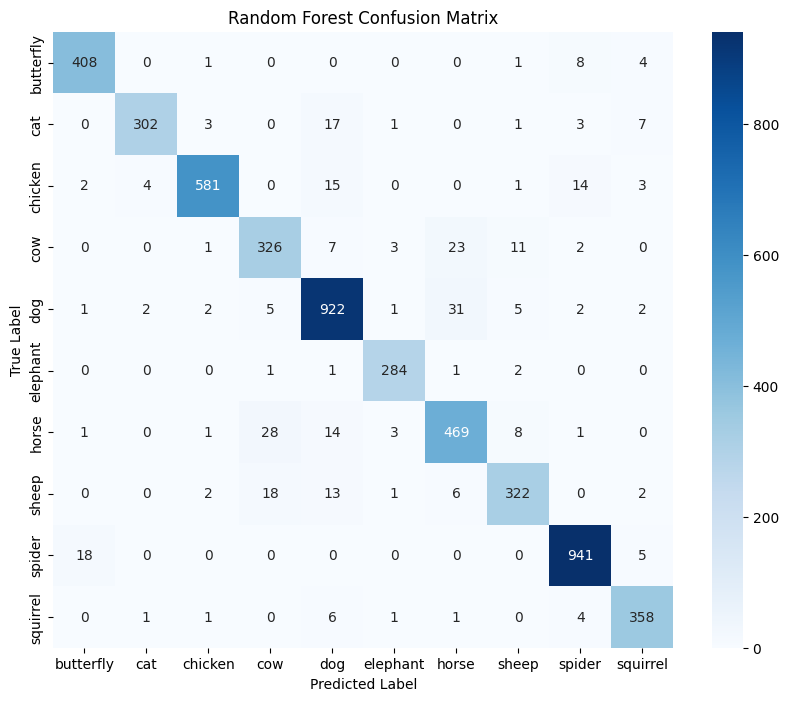

In [ ]:
y_pred_rf = grid_search_rf.best_estimator_.predict(X_test_pca)

print(f"Best parameters found by Random Forest GridSearchCV: {grid_search_rf.best_params_}")
print(f"Random Forest Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

print("\nRandom Forest Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()